In [1]:
from pathlib import Path
from sklearn.svm import LinearSVC

import importlib
import functions
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
importlib.reload(functions)
from tqdm.notebook import tqdm
import math
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score, accuracy_score
)
import shap
import matplotlib.pyplot as plt
import seaborn as sns

functions.set_seed(1905)

In [2]:
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "datasets/SVM-Linear"
OUTPUT_FIG = PROJECT_ROOT / "figures/SVM-Linear"
OUTPUT_IMP = PROJECT_ROOT / "datasets/FeatureImp"
OUTPUT_TEX = PROJECT_ROOT / "tex/SVM-Linear"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_IMP.mkdir(parents=True, exist_ok=True)
OUTPUT_TEX.mkdir(parents=True, exist_ok=True)

In [3]:
aap_symbols = pd.read_csv(PROJECT_ROOT / 'datasets/exp_mat_unscaled.csv', index_col=0).index
aap_symbols

Index(['CYSLTR1', 'PRXL2B', 'PTGS2', 'PTGER4', 'PNPLA8', 'LIPA', 'PTGER2',
       'LTB4R', 'ABCC1', 'CYSLTR2',
       ...
       'GPX7', 'PLA2G4A', 'EPHX2', 'ACOT11', 'ABCC6', 'MGST3', 'ACSL4',
       'CYP4F3', 'ALOX15B', 'LTA4H'],
      dtype='object', length=103)

In [4]:
#whole dataset
dataset = functions.GeneExpressionDataset(
    exp_matrix_path= PROJECT_ROOT / 'datasets/exp_mat_unscaled.csv',
    conf_matrix_path= PROJECT_ROOT / 'datasets/adj_giant.csv',
    threshold=0.1
)

k = 10
n = 9
split_seed = 1905
y = np.array([data.y.item() for data in dataset])
country = np.array(dataset.country)
strat = np.array([f"{label}__{group}" for label, group in zip(y, country)])
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=split_seed)

C:\Users\fabia\Desktop\Git_Repos\aap-transcriptomic-analysis\functions.py:174: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


In [6]:
H = [{"model": "SVM","kernel" : "linear","C": C} for C in [5e-3, 1e-2, 5e-2, 1e-1, 1, 10]]
t_scores = []
fold_acc = []
all_y_true = []
all_y_pred = []
cms = []

X_test_list = []
X_unscaled_test_list = []
expected_values = []
shap_values_test_folds = []
decision_scores =[]

metrics_u_j = {
    "Accuracy": pd.DataFrame(columns=range(k)),
    "F1": pd.DataFrame(columns=range(k)),
    "Precision": pd.DataFrame(columns=range(k)),
    "Recall": pd.DataFrame(columns=range(k)),
    "AUC-PRC": pd.DataFrame(columns=range(k)),
    "AUC-ROC": pd.DataFrame(columns=range(k))
}

metrics_t = {
    "Accuracy": np.array([]),
    "F1": np.array([]),
    "Precision": np.array([]),
    "Recall": np.array([]),
    "AUC-PRC": np.array([]),
    "AUC-ROC": np.array([])
}

D = np.array([data.y.item() for data in dataset])

folds: [np.ndarray] = []
for _, fold_idx in skf.split(np.zeros(len(D)), strat):
    folds.append(fold_idx)

#Progress bar
total = k*len(H)*(k-1)
pbar = tqdm(total=total, desc="Verarbeitung läuft")

for i in range(k):
    test_idx = folds[i]
    other_fold_ids = [m for m in range(k) if m != i]
    # Outer folds
    best_j = None
    best_ubar = -math.inf
    pd.DataFrame(test_idx, columns=["index"]).to_csv(PROJECT_ROOT / ("datasets/SVM-Linear/" +f"fold_{i}_test.csv"), index=False)

    for j, h_j in enumerate(H):
        u_vals = {m: [] for m in metrics_u_j.keys()}

        # inner CV loop
        for m in other_fold_ids:
            val_idx = folds[m]
            train_fold_ids = [r for r in range(k) if r not in (i, m)]
            train_idx = np.concatenate([folds[r] for r in train_fold_ids], axis=0)

            pd.DataFrame(train_idx, columns=["index"]).to_csv(PROJECT_ROOT / ("datasets/SVM-Linear/" + f"fold_{m}_train.csv"), index=False)
            pd.DataFrame(val_idx, columns=["index"]).to_csv(PROJECT_ROOT / ("datasets/SVM-Linear/" + f"fold_{m}_val.csv"), index=False)
            functions.removeBatchEffect(PROJECT_ROOT / ("datasets/SVM-Linear/" + f"fold_{m}_train.csv"),
                      PROJECT_ROOT / ("datasets/SVM-Linear/" + f"fold_{m}_val.csv"),
                      str(m), "SVM-Linear")

            train_dataset = functions.GeneExpressionDataset(
                exp_matrix_path= PROJECT_ROOT / ("datasets/SVM-Linear/" + f"train_corrected_{m}.csv"),
                conf_matrix_path= PROJECT_ROOT / "datasets" / "adj_giant.csv",
                threshold=0.1
            )
            val_dataset = functions.GeneExpressionDataset(
                exp_matrix_path= PROJECT_ROOT / ("datasets/SVM-Linear/" + f"val_corrected_{m}.csv"),
                conf_matrix_path= PROJECT_ROOT / "datasets" / "adj_giant.csv",
                threshold=0.1
            )

            scaler = StandardScaler()
            #calculate mean and sd on training data
            scaler.fit(train_dataset.expr)
            
            X_train = scaler.transform(train_dataset.expr)
            y_train = train_dataset.labels
            X_val = scaler.transform(val_dataset.expr)
            y_val = val_dataset.labels
            
            model = LinearSVC(C=h_j['C'], class_weight="balanced")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            y_prob = model.decision_function(X_val)
            
            u_vals['Precision'].append(precision_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['Recall'].append(recall_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['Accuracy'].append(accuracy_score(y_val, y_pred))
            u_vals['F1'].append(f1_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['AUC-PRC'].append(average_precision_score(y_val, y_prob))
            u_vals['AUC-ROC'].append(roc_auc_score(y_val, y_prob))
            pbar.update(1)

        ubar_j = float(np.mean(u_vals["Recall"]))
        for metric in metrics_u_j.keys():
            mean = np.mean(u_vals[metric])
            std = np.std(u_vals[metric])
            metrics_u_j[metric].loc[j, i] = f"{mean:.3f} ± {std:.3f}" 

        if ubar_j > best_ubar:
            best_ubar = ubar_j
            best_j = j
    
    assert best_j is not None
    h_star = H[best_j]

    #outer cv loop
    train_idx_full = np.concatenate([folds[r] for r in range(k) if r != i], axis=0)
    
    pd.DataFrame(train_idx_full, columns=["index"]).to_csv(PROJECT_ROOT / ("datasets/SVM-Linear/" + f"fold_{i}_train_full.csv"), index=False)
    functions.removeBatchEffect(PROJECT_ROOT / ("datasets/SVM-Linear/" + f"fold_{i}_train_full.csv"),
                      PROJECT_ROOT / ("datasets/SVM-Linear/" +f"fold_{i}_test.csv"),
                      str(i), "SVM-Linear")

    train_dataset = functions.GeneExpressionDataset(
        exp_matrix_path= PROJECT_ROOT / ("datasets/SVM-Linear/" + f"train_corrected_{i}.csv"),
        conf_matrix_path= PROJECT_ROOT / "datasets" / "adj_giant.csv",
        threshold=0.1
    )
    test_dataset = functions.GeneExpressionDataset(
        exp_matrix_path= PROJECT_ROOT / ("datasets/SVM-Linear/" + f"test_corrected_{i}.csv"),
        conf_matrix_path= PROJECT_ROOT / "datasets" / "adj_giant.csv",
        threshold=0.1
    )

    #calculate mean and sd on training data
    scaler = StandardScaler()
    scaler.fit(train_dataset.expr)

    X_train = scaler.transform(train_dataset.expr)
    y_train = train_dataset.labels
    X_test = scaler.transform(test_dataset.expr)
    y_test = test_dataset.labels
    
    model = LinearSVC(C=h_j['C'], class_weight="balanced")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.decision_function(X_test)

    metrics_t['Precision'] = np.append(metrics_t['Precision'], precision_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['Recall'] = np.append(metrics_t['Recall'], recall_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['Accuracy'] = np.append(metrics_t['Accuracy'], accuracy_score(y_test, y_pred))
    metrics_t['F1'] = np.append(metrics_t['F1'], f1_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['AUC-PRC'] = np.append(metrics_t['AUC-PRC'], average_precision_score(y_test, y_prob))
    metrics_t['AUC-ROC'] = np.append(metrics_t['AUC-ROC'], roc_auc_score(y_test, y_prob))

    X_test_list.append(X_test)
    X_unscaled_test_list.append(test_dataset.expr)
    
    explainer = shap.LinearExplainer(model, X_train)
    shap_values = explainer.shap_values(X_test)
    shap_values_test_folds.append(shap_values)
    expected_values.extend([explainer.expected_value] * len(X_test))
    
    t_scores.append(accuracy_score(y_test, y_pred))
    all_y_true.append(y_test)
    all_y_pred.append(y_pred)
    decision_scores.append(y_prob)
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    cms.append(cm)
pbar.close()
    
mean = float(np.mean(t_scores))
std = float(np.std(t_scores, ddof=1))
print(mean, std)

Verarbeitung läuft:   0%|          | 0/540 [00:00<?, ?it/s]

0.6088269454123112 0.0744677512410276


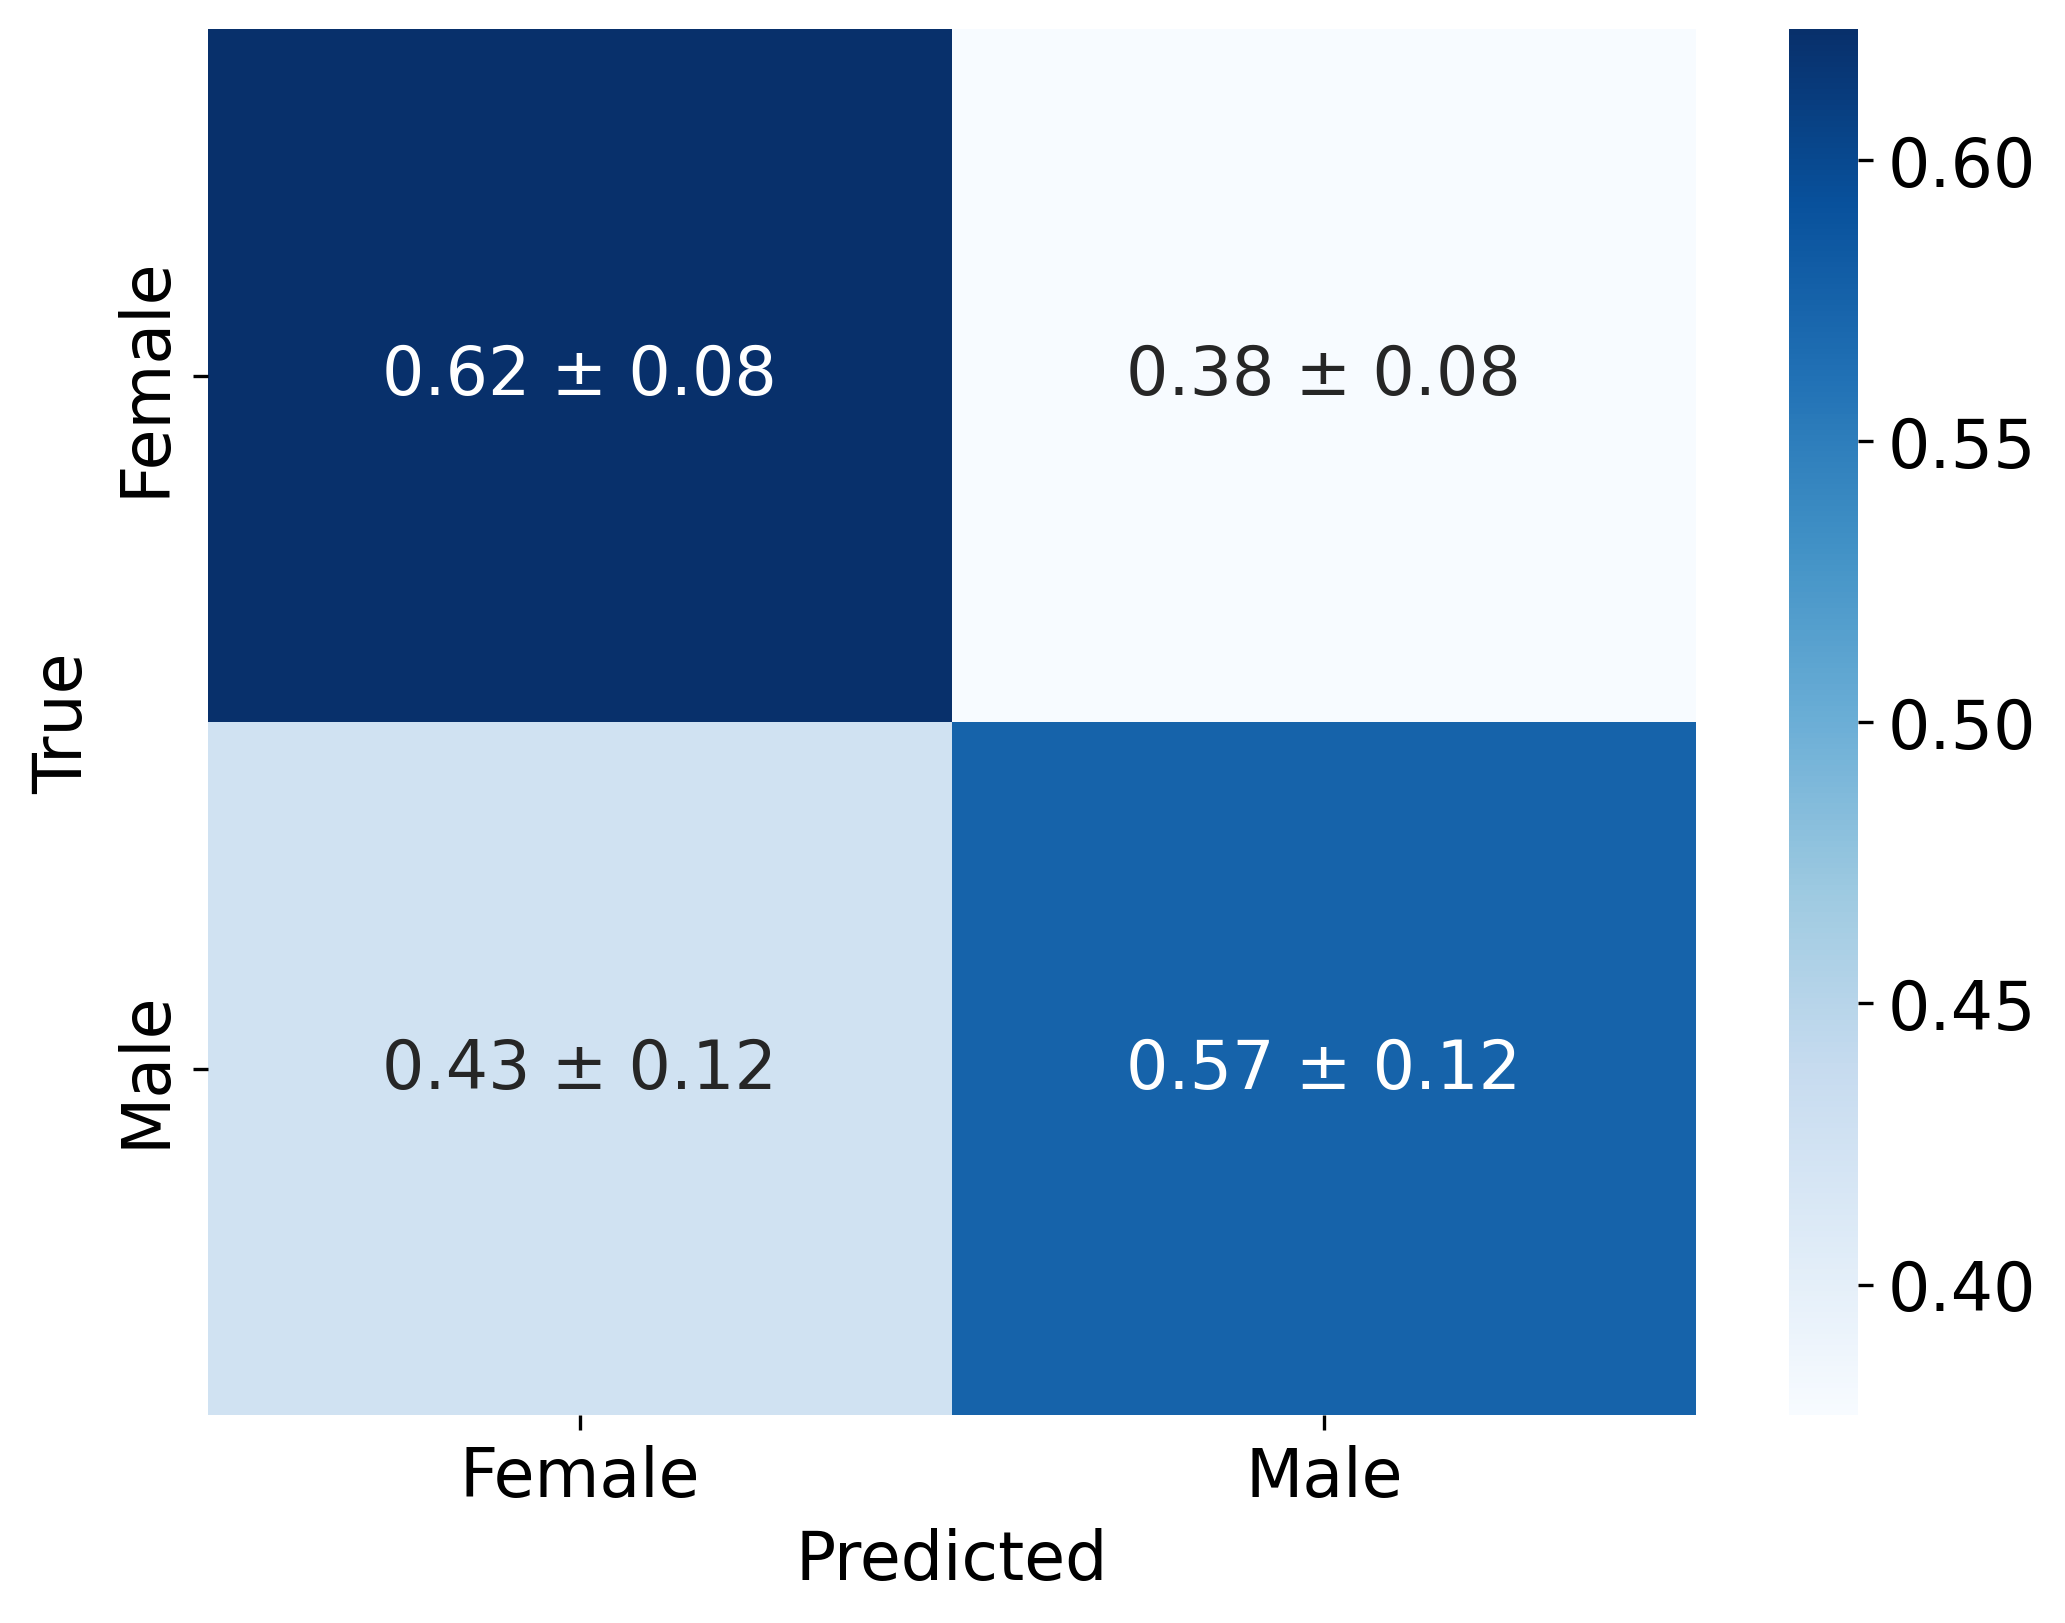

In [7]:
cms = np.array(cms)

cm_mean = np.mean(cms, axis=0)
cm_std  = np.std(cms, axis=0)

labels = np.array([
    [f"{m:.2f} ± {s:.2f}" for m, s in zip(row_m, row_s)]
    for row_m, row_s in zip(cm_mean, cm_std)
])

plt.figure(figsize=(8, 6), dpi=300)

labels_names = ["Female", "Male"]
ax = sns.heatmap(cm_mean, annot=labels, fmt="", cmap="Blues", xticklabels=labels_names, yticklabels=labels_names, annot_kws={"size": 16})
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_xlabel("Predicted", fontsize=16)
ax.set_ylabel("True", fontsize=16)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

#plt.savefig(PROJECT_ROOT / "figures/SVM-Linear/confusion_matrix_svm-linear.pdf", bbox_inches="tight")
plt.show()

In [10]:
#generates NACHOS Latex tables
for metric in metrics_u_j.keys():
    df_cv = metrics_u_j[metric]
    df_cv.columns = [f"F{i}" for i in range(k)]
    df_cv.index = [f"h_{i}" for i in range(len(H))]
  
    cross_scores = {f"t{i}": metrics_t[metric][i] for i in range(k)}
    functions.generate_table_nachos_tex(df_cv=df_cv,
                            caption="NACHOS " + metric + " results for " + H[0]['model'],
                            cross_scores=cross_scores,
                            metric=metric,
                            filename=OUTPUT_TEX / ("table_nachos_" + metric + ".tex"),
                            label = "tab:" + H[0]['kernel'] + " " + H[0]['model'] + metric if H[0]['model'] == "SVM" 
                            else "tab:" + H[0]['model'] + metric) 

In [11]:
metrics_u_j

{'Accuracy':                 F0             F1             F2             F3  \
 h_0  0.600 ± 0.048  0.632 ± 0.053  0.616 ± 0.052  0.627 ± 0.056   
 h_1  0.619 ± 0.055  0.635 ± 0.060  0.626 ± 0.054  0.637 ± 0.061   
 h_2  0.627 ± 0.080  0.608 ± 0.056  0.605 ± 0.045  0.618 ± 0.067   
 h_3  0.627 ± 0.082  0.610 ± 0.044  0.616 ± 0.059  0.613 ± 0.064   
 h_4  0.624 ± 0.081  0.621 ± 0.047  0.616 ± 0.063  0.605 ± 0.073   
 h_5  0.624 ± 0.081  0.626 ± 0.046  0.616 ± 0.060  0.602 ± 0.074   
 
                 F4             F5             F6             F7  \
 h_0  0.585 ± 0.044  0.609 ± 0.048  0.603 ± 0.044  0.622 ± 0.066   
 h_1  0.579 ± 0.059  0.633 ± 0.043  0.587 ± 0.068  0.630 ± 0.072   
 h_2  0.587 ± 0.062  0.608 ± 0.047  0.579 ± 0.074  0.630 ± 0.088   
 h_3  0.587 ± 0.059  0.606 ± 0.049  0.590 ± 0.072  0.628 ± 0.093   
 h_4  0.598 ± 0.048  0.608 ± 0.048  0.571 ± 0.064  0.625 ± 0.073   
 h_5  0.598 ± 0.048  0.608 ± 0.049  0.571 ± 0.065  0.620 ± 0.081   
 
                 F8             

In [12]:
metrics_t

{'Accuracy': array([0.69047619, 0.5952381 , 0.5       , 0.5952381 , 0.70731707,
        0.68292683, 0.6097561 , 0.58536585, 0.48780488, 0.63414634]),
 'F1': array([0.67557932, 0.5523511 , 0.49281196, 0.58941921, 0.6925    ,
        0.67037724, 0.59803922, 0.54651919, 0.45540797, 0.58585859]),
 'Precision': array([0.67620137, 0.55185185, 0.50681818, 0.60227273, 0.69082126,
        0.6722488 , 0.60047847, 0.55147059, 0.47248804, 0.58465608]),
 'Recall': array([0.69642857, 0.55357143, 0.50740741, 0.61111111, 0.70899471,
        0.69047619, 0.60769231, 0.56034483, 0.46695402, 0.58791209]),
 'AUC-PRC': array([0.53003229, 0.41654962, 0.45516606, 0.66499041, 0.59361143,
        0.49685332, 0.71277219, 0.45687211, 0.38004588, 0.53818918]),
 'AUC-ROC': array([0.70153061, 0.54846939, 0.57037037, 0.6962963 , 0.75925926,
        0.67989418, 0.76410256, 0.57471264, 0.51436782, 0.70054945])}

C:\Users\fabia\AppData\Local\Temp\ipykernel_4456\3949101505.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_top,X_top,plot_type="bar",feature_names=names_top,show=False)


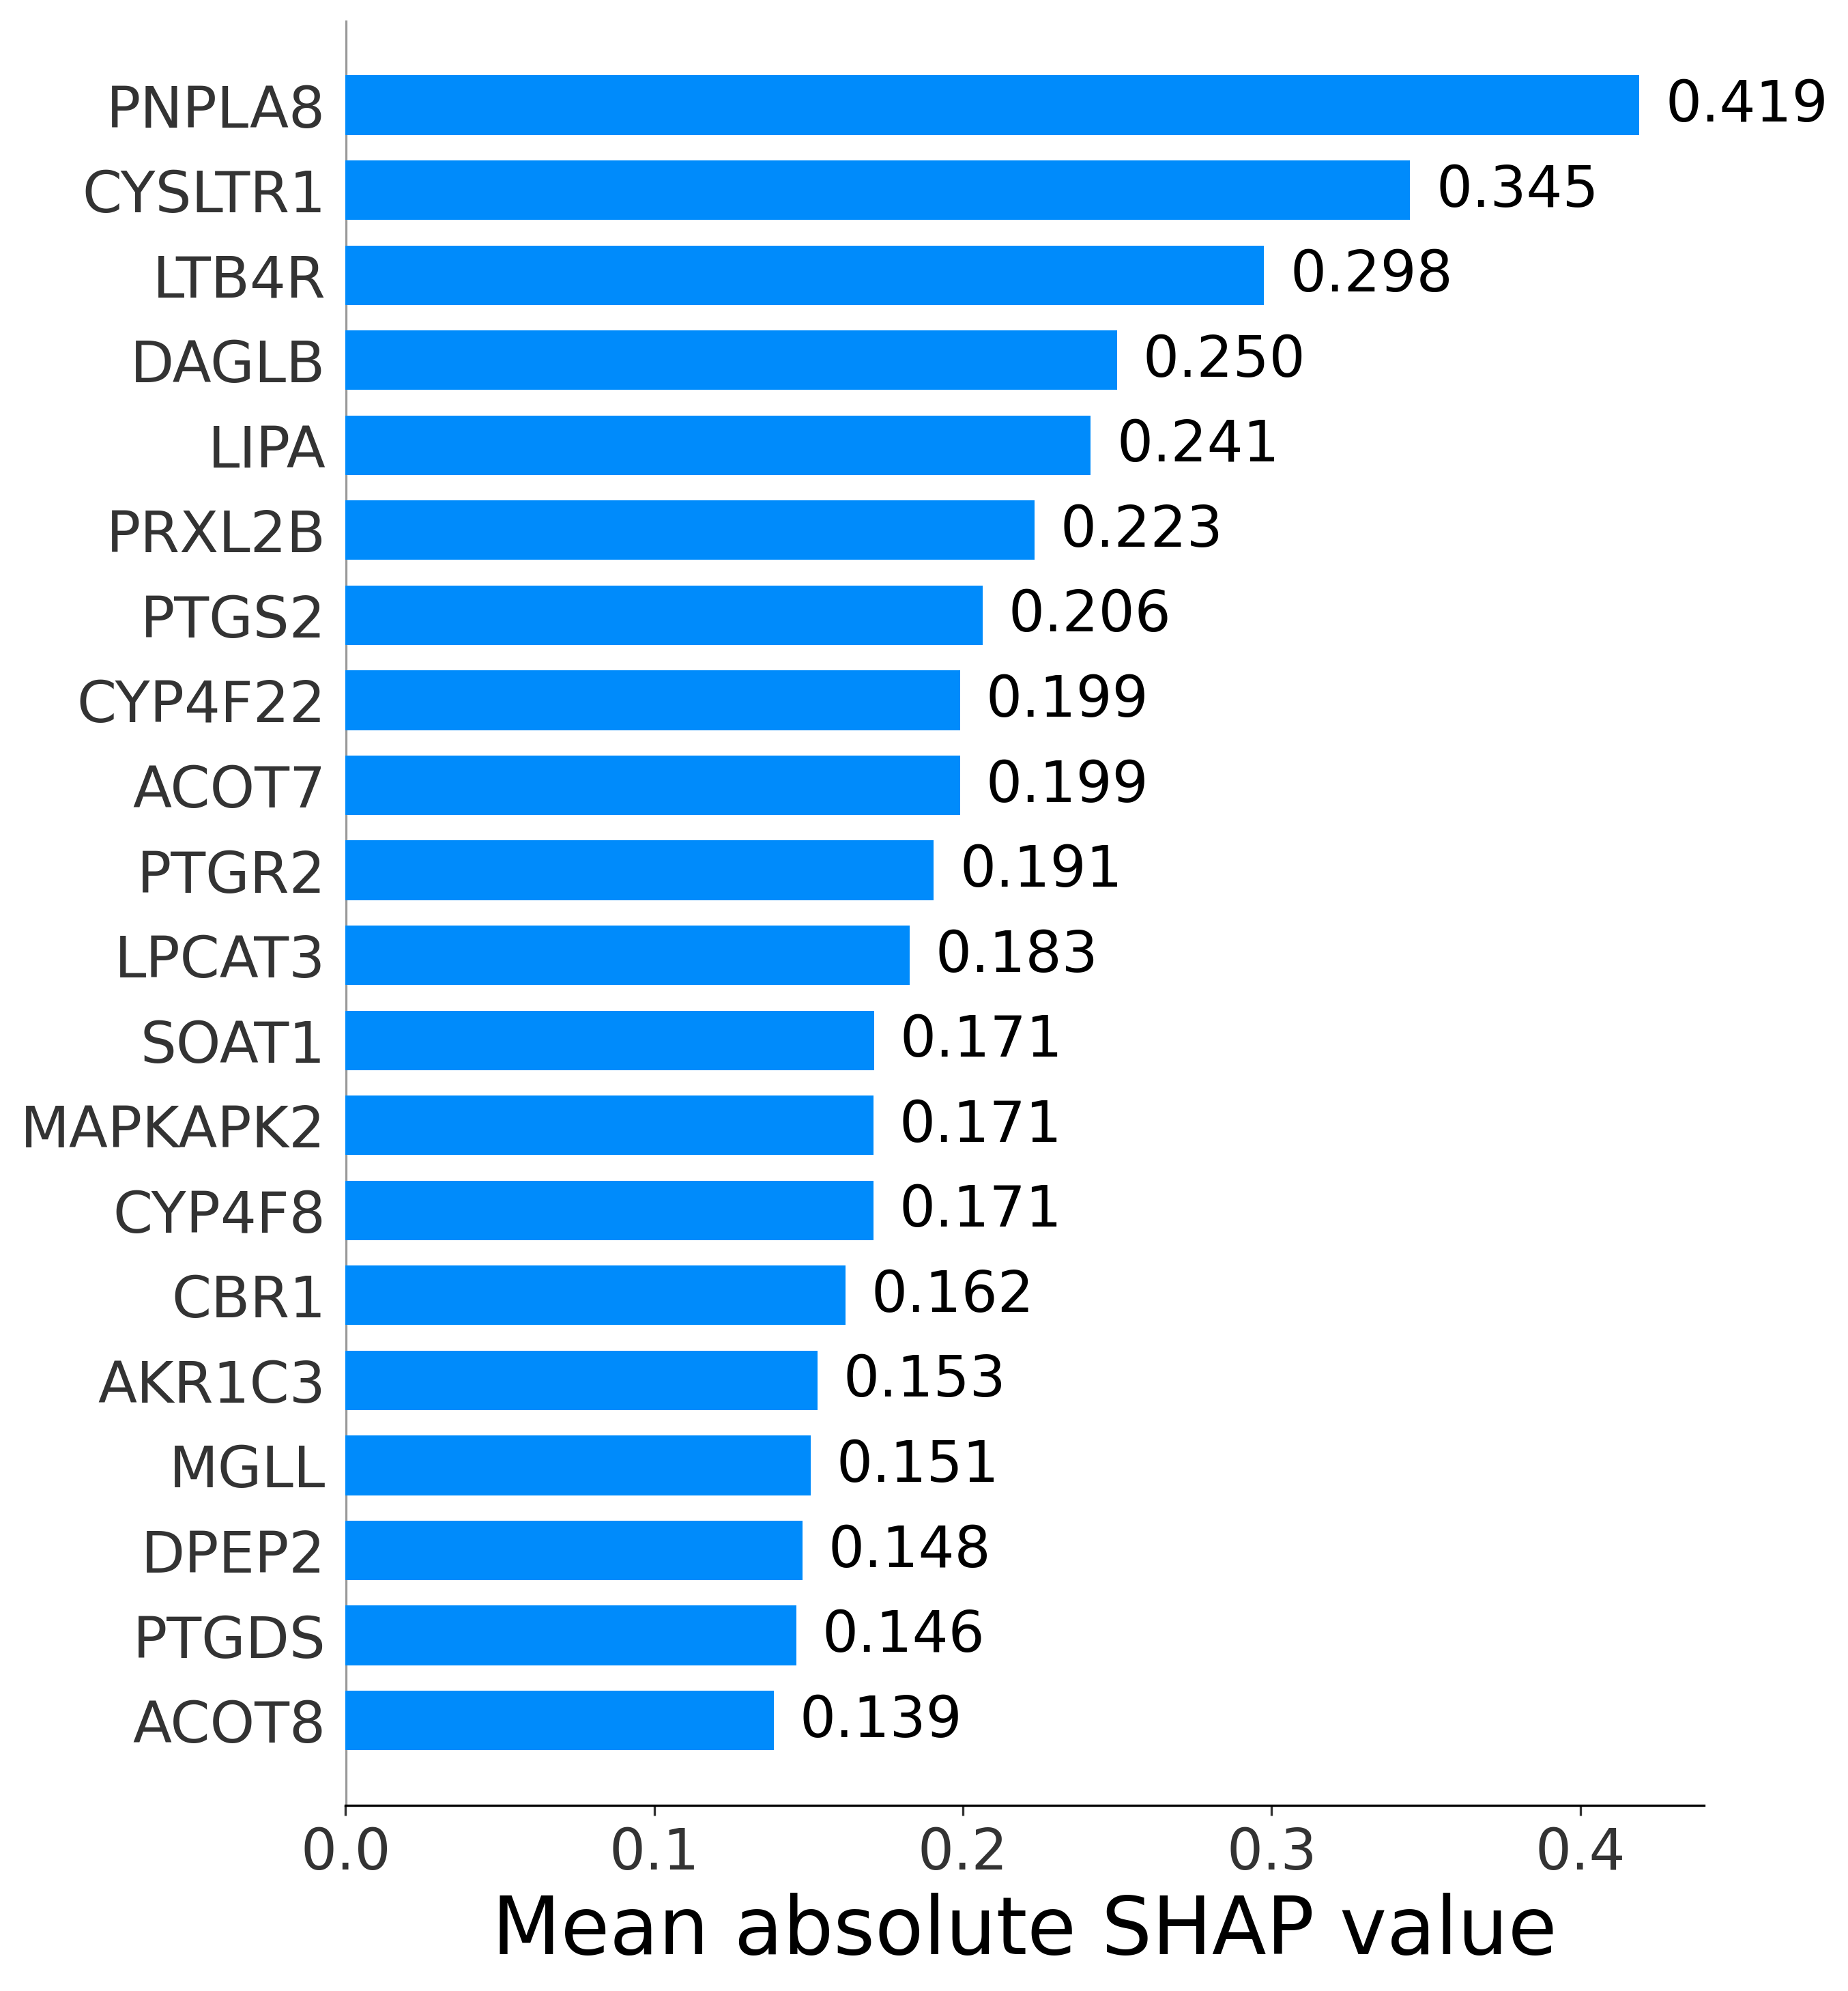

In [13]:
X_test_all = np.vstack(X_test_list)
shap_all = np.vstack(shap_values_test_folds)

importance = np.mean(np.abs(shap_all), axis=0)
top_idx = np.argsort(importance)[::-1][:20]

shap_top = shap_all[:, top_idx]
X_top = X_test_all[:, top_idx]
names_top = np.array(aap_symbols)[top_idx]
importance_top = importance[top_idx]

pd.DataFrame({"Symbols": aap_symbols[np.argsort(importance)[::-1]], "LinearSVMImp": importance[np.argsort(importance)[::-1]]}).to_csv(OUTPUT_IMP / "linearsvmimp.csv", index=False, sep=";")

fig = plt.figure(figsize=(12, 6),dpi=300)
shap.summary_plot(shap_top,X_top,plot_type="bar",feature_names=names_top,show=False)

ax = plt.gca()
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel("Mean absolute SHAP value", fontsize=28)


offset = max(importance_top) * 0.02

for i, v in enumerate(importance_top[::-1]):
    ax.text(v + offset, i, f"{v:.3f}", va='center', fontsize=20)

plt.xlabel("Mean absolute SHAP value")
#plt.savefig(PROJECT_ROOT / "figures/SVM-Linear/shap_summary_svm-linear-bar.pdf", bbox_inches="tight")
plt.show()
plt.close()

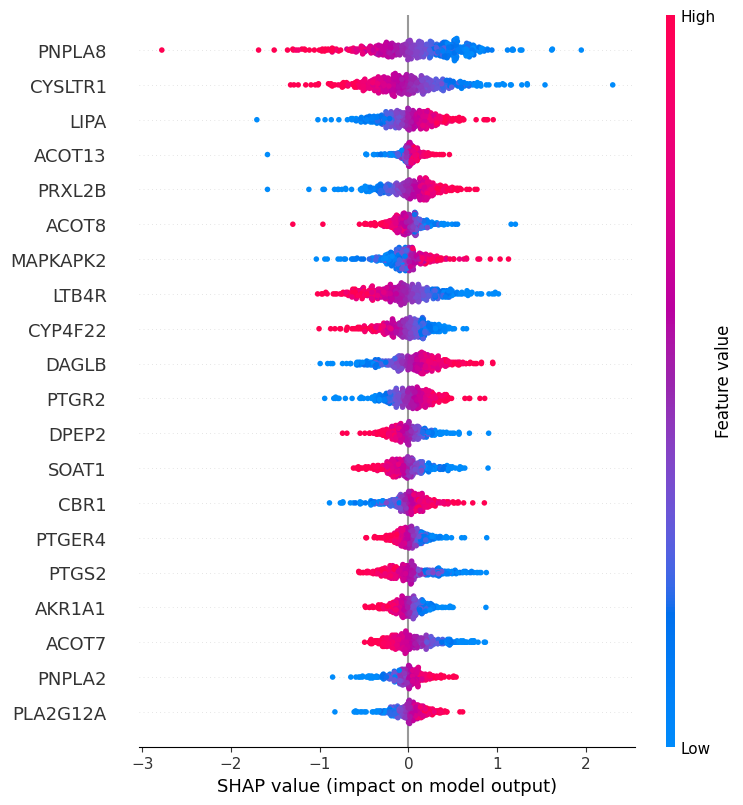

In [14]:
importance = np.max(np.abs(shap_all), axis=0)
order = np.argsort(importance)[::-1]
all_base_values = np.zeros(len(X_test_all))
X_unscaled_test_all = np.vstack(X_unscaled_test_list)

explanation = shap.Explanation(
    values=shap_all,
    data=X_test_all,
    feature_names=aap_symbols,
    base_values=expected_values
)
explanation.data = X_unscaled_test_all

fig = plt.figure(figsize=(12, 6), dpi=300)
shap.plots.beeswarm(explanation, max_display=20, show=False, order=order, group_remaining_features=False)
ax = plt.gca()
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=28)

cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=20)
cbar.set_ylabel("Feature value", fontsize=20)
plt.gcf().canvas.draw()

plt.subplots_adjust(top=0.95)

#fig.savefig(PROJECT_ROOT / "figures/SVM-Linear/shap_summary_svm-linear.pdf", bbox_inches="tight")
plt.close()
shap.plots.beeswarm(explanation, max_display=20, show=True, order=order, group_remaining_features=False)

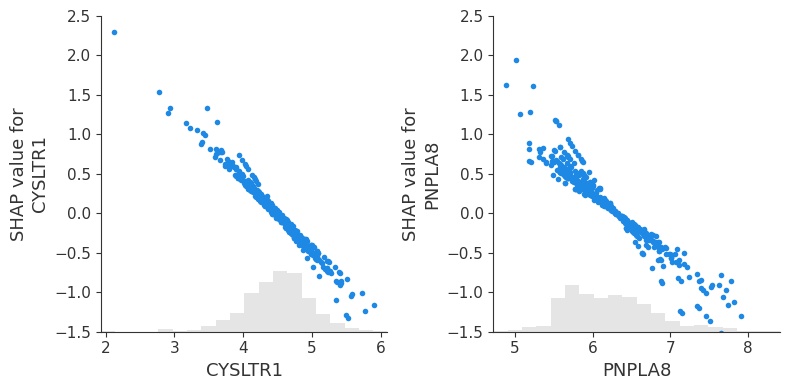

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()

shap.plots.scatter(
    explanation[:, "CYSLTR1"],
    ax=axes[0],
    show=False
)
shap.plots.scatter(
    explanation[:, "PNPLA8"],
    ax=axes[1],
    show=False
)
#shap.plots.scatter(
#    explanation[:, "PTGS2"],
#    ax=axes[2],
#    show=False
#)
#shap.plots.scatter(
#    explanation[:, "ACOT13"],
#    ax=axes[3],
#    show=False
#)
for ax in axes:
    ax.set_ylim(-1.5, 2.5)

plt.tight_layout()
#fig.savefig(PROJECT_ROOT / "figures/SVM-Linear/scatter_plots.pdf", bbox_inches="tight")
plt.show()

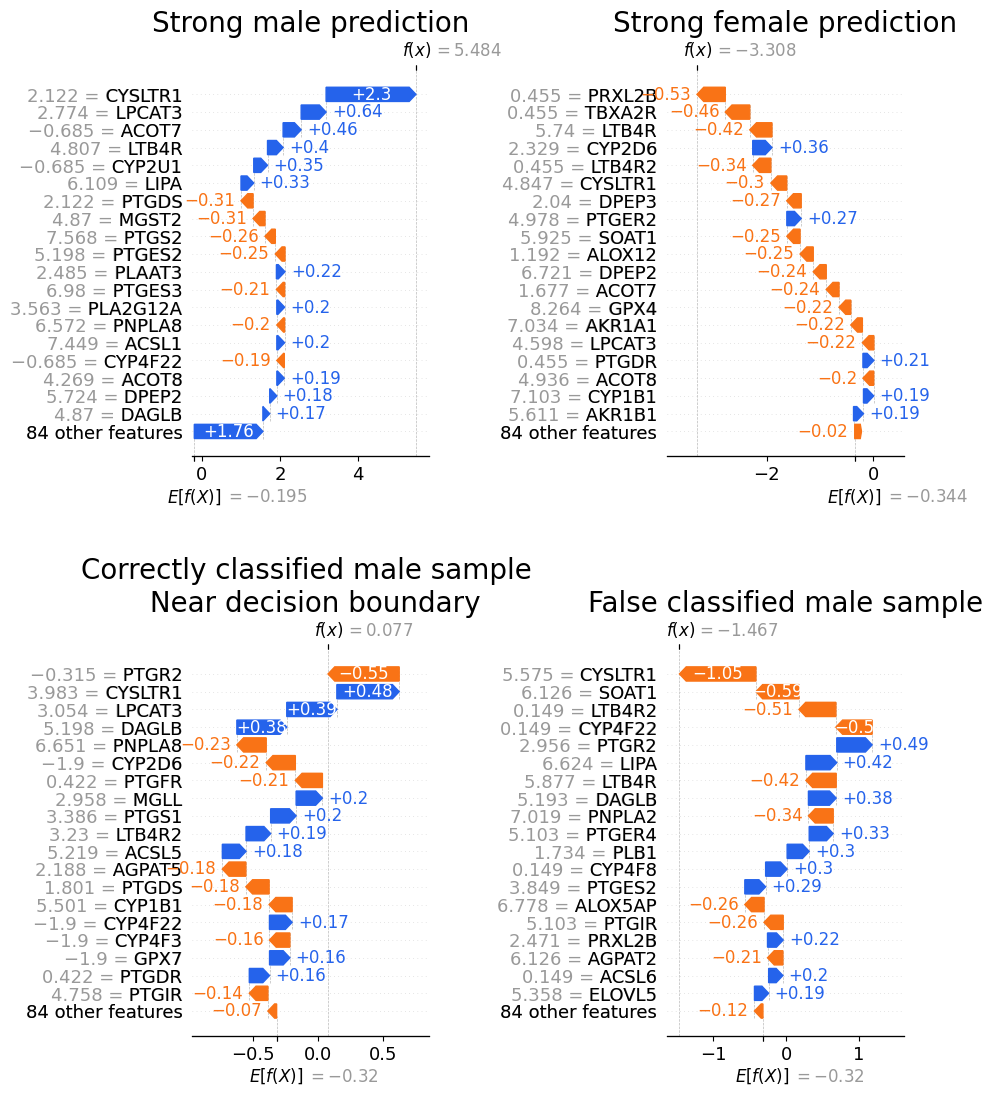

In [16]:
stacked_preds = np.hstack(all_y_pred)
stacked_trues = np.hstack(all_y_true)
stacked_decision_scores = np.hstack(decision_scores)

idx_high = np.argmax(stacked_decision_scores)
idx_low = np.argsort(stacked_decision_scores)[1]
log_odds = expected_values + np.sum(shap_all, axis=1)
idx_median = np.where(abs(log_odds) <= 0.1)[0][0]
#idx_median = np.argsort(stacked_decision_scores)[len(stacked_decision_scores) // 2]
idx_wrong = np.where(stacked_preds != stacked_trues)[0][0]

fig = plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
shap.plots.waterfall(explanation[idx_high], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Strong male prediction", fontsize=20)

plt.subplot(2, 2, 2)
shap.plots.waterfall(explanation[idx_low], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Strong female prediction", fontsize=20)

plt.subplot(2, 2, 3)
shap.plots.waterfall(explanation[idx_median], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Correctly classified male sample \n Near decision boundary", fontsize=20)

plt.subplot(2, 2, 4)
shap.plots.waterfall(explanation[idx_wrong], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("False classified male sample", fontsize=20)

plt.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.08, wspace=1, hspace=0.5)
#fig.savefig(PROJECT_ROOT / "figures/SVM-Linear/waterfall.pdf", bbox_inches="tight")
plt.show()

In [17]:
print(stacked_preds[idx_wrong], stacked_trues[idx_wrong])
print(stacked_preds[idx_median], stacked_trues[idx_median])

0 1
1 1
